# 03 · Entrenamiento y comparación de modelos

## Predicción del riesgo de rotura de stock en un entorno logístico

En este notebook entreno varios modelos de clasificación para predecir la variable `stockout_risk`.

Comparo cuatro opciones:

1. Dummy Classifier como referencia mínima.
2. Regresión logística.
3. Random Forest.
4. XGBoost.

La separación entre entrenamiento y test se realiza por fecha. De esta forma, entreno con datos anteriores y evalúo con fechas más recientes.

> El target es sintético porque el dataset original no contiene roturas de stock reales. Por tanto, los resultados deben interpretarse como una evaluación de la regla simulada creada en el notebook anterior.


## 1. Importación de librerías

Importo las herramientas necesarias para preparar los datos, entrenar los modelos, calcular métricas y guardar los resultados.

Utilizo `Pipeline` en la regresión logística para aplicar el escalado y el modelo dentro del mismo proceso.


In [1]:
from pathlib import Path
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBClassifier
except ImportError:
    raise ImportError(
        "XGBoost no está instalado. "
        "Ejecuta: pip install xgboost"
    )

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

RANDOM_STATE = 42
TARGET = "stockout_risk"
TEST_SIZE = 0.20
THRESHOLD = 0.50

# Limito el número de filas para que el entrenamiento sea viable
# en un equipo normal.
MAX_TRAIN_ROWS = 500_000
MAX_TEST_ROWS = 200_000


## 2. Definición de rutas

Utilizo la misma estructura de carpetas que en los notebooks anteriores.

Guardo por separado los modelos, las métricas, las predicciones y las imágenes.


In [2]:
current_path = Path.cwd()

if current_path.name == "notebooks":
    project_path = current_path.parent
else:
    project_path = current_path

data_path = project_path / "data" / "processed" / "stockout_dataset.csv"

models_path = project_path / "models"
metrics_path = project_path / "outputs" / "metrics"
predictions_path = project_path / "outputs" / "predictions"
figures_path = project_path / "outputs" / "figures" / "model_training"

models_path.mkdir(parents=True, exist_ok=True)
metrics_path.mkdir(parents=True, exist_ok=True)
predictions_path.mkdir(parents=True, exist_ok=True)
figures_path.mkdir(parents=True, exist_ok=True)

print("Dataset procesado:", data_path)


Dataset procesado: c:\Users\lloro\Documents\GitHub\TFE_PROYECTO1\data\processed\stockout_dataset.csv


## 3. Carga del dataset

Cargo el dataset creado en el notebook de ingeniería de variables.

Compruebo que existen la fecha, el target y las variables que voy a utilizar.


In [3]:
if not data_path.exists():
    raise FileNotFoundError(
        f"No se encuentra el archivo: {data_path}"
    )

df = pd.read_csv(
    data_path,
    parse_dates=["date"]
)

model_features = [
    "sales",
    "price",
    "promo",
    "year",
    "month",
    "week",
    "weekday",
    "is_weekend",
    "sales_lag_1",
    "sales_lag_7",
    "sales_lag_14",
    "sales_lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_std_30",
    "trend_7_30",
    "rolling_price_mean_30",
    "promo_days_last_7",
    "lead_time_days"
]

required_columns = [
    "date",
    "store_id",
    "item_id",
    TARGET,
    *model_features
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Faltan columnas necesarias: {missing_columns}"
    )

df = df.sort_values(
    ["date", "store_id", "item_id"]
).reset_index(drop=True)

print("Shape del dataset:", df.shape)
display(df.head())


Shape del dataset: (4472500, 34)


,date,store_id,item_id,sales,price,promo,weekday,month,year,week,is_weekend,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_30,trend_7_30,rolling_price_mean_30,promo_days_last_7,lead_time_days,future_sales_d1,future_sales_d2,future_sales_d3,future_sales_d4,future_sales_d5,future_sales_d6,future_sales_d7,future_demand_7d,stock_estimated,safety_stock,stockout_risk
0,2019-01-31,store_1,item_1,50,21.3000,0,3,1,2019,5,0,57.0000,40.0000,46.0000,41.0000,42.7143,42.1429,42.7667,6.2515,-0.0524,21.0160,0.0000,2,41.0000,34.0000,34.0000,64.0000,54.0000,58.0000,53.0000,338.0000,85.5333,8.8410,1
1,2019-01-31,store_1,item_10,36,16.4700,1,3,1,2019,5,0,44.0000,24.0000,24.0000,18.0000,21.8571,22.9286,21.3667,6.9207,0.4905,20.1780,1.0000,4,22.0000,25.0000,17.0000,18.0000,22.0000,23.0000,23.0000,150.0000,85.4667,13.8413,1
2,2019-01-31,store_1,item_11,26,65.2500,0,3,1,2019,5,0,29.0000,21.0000,24.0000,27.0000,21.5714,22.2857,22.6333,5.6598,-1.0619,64.8150,0.0000,5,26.0000,20.0000,22.0000,23.0000,26.0000,25.0000,25.0000,167.0000,113.1667,12.6557,1
3,2019-01-31,store_1,item_12,20,60.8800,0,3,1,2019,5,0,26.0000,23.0000,19.0000,13.0000,22.5714,21.4286,19.5000,5.4819,3.0714,58.8500,2.0000,6,15.0000,14.0000,14.0000,23.0000,26.0000,25.0000,20.0000,137.0000,117.0000,13.4280,1
4,2019-01-31,store_1,item_13,37,68.1900,0,3,1,2019,5,0,47.0000,43.0000,39.0000,41.0000,38.2857,37.0000,37.1000,7.9236,1.1857,67.2807,0.0000,7,32.0000,33.0000,33.0000,39.0000,45.0000,49.0000,45.0000,276.0000,259.7000,20.9638,0


## 4. Revisión del target

Antes de entrenar, reviso cuántos registros pertenecen a cada clase.

Esta comprobación me ayuda a interpretar las métricas y a saber si existe un desbalance importante.


In [4]:
target_distribution = (
    df[TARGET]
    .value_counts()
    .sort_index()
    .rename_axis(TARGET)
    .reset_index(name="count")
)

target_distribution["proportion"] = (
    target_distribution["count"]
    / len(df)
)

display(target_distribution)

target_distribution.to_csv(
    metrics_path / "training_target_distribution.csv",
    index=False
)


,stockout_risk,count,proportion
0,0,685980,0.1534
1,1,3786520,0.8466


## 5. Separación temporal entre entrenamiento y test

No realizo una división aleatoria porque estoy trabajando con datos temporales.

Utilizo las fechas más antiguas para entrenar y reservo el 20 % de fechas más recientes para evaluar.


In [5]:
unique_dates = np.sort(
    df["date"].dropna().unique()
)

cut_position = int(
    len(unique_dates) * (1 - TEST_SIZE)
)

cut_date = unique_dates[cut_position]

train_df = df[
    df["date"] < cut_date
].copy()

test_df = df[
    df["date"] >= cut_date
].copy()

print("Fecha de corte:", pd.Timestamp(cut_date))
print("Train original:", train_df.shape)
print("Test original:", test_df.shape)


Fecha de corte: 2023-01-01 00:00:00
Train original: (3577500, 34)
Test original: (895000, 34)


## 6. Reducción del tamaño para el entrenamiento

El dataset contiene varios millones de filas. Entrenar todos los modelos con el dataset completo puede superar la memoria disponible o tardar demasiado.

Por este motivo utilizo una muestra reproducible dentro de train y test.

Mantengo la separación temporal: primero realizo el corte por fecha y después tomo la muestra dentro de cada conjunto.


In [6]:
if len(train_df) > MAX_TRAIN_ROWS:
    train_df = train_df.sample(
        n=MAX_TRAIN_ROWS,
        random_state=RANDOM_STATE
    )

if len(test_df) > MAX_TEST_ROWS:
    test_df = test_df.sample(
        n=MAX_TEST_ROWS,
        random_state=RANDOM_STATE
    )

train_df = train_df.sort_values(
    ["date", "store_id", "item_id"]
).reset_index(drop=True)

test_df = test_df.sort_values(
    ["date", "store_id", "item_id"]
).reset_index(drop=True)

print("Train utilizado:", train_df.shape)
print("Test utilizado:", test_df.shape)


Train utilizado: (500000, 34)
Test utilizado: (200000, 34)


## 7. Preparación de X e y

Separo las variables predictoras del target.

Compruebo también que no existan valores nulos en las columnas que utilizarán los modelos.


In [7]:
X_train = train_df[model_features].copy()
y_train = train_df[TARGET].astype(int).copy()

X_test = test_df[model_features].copy()
y_test = test_df[TARGET].astype(int).copy()

if X_train.isna().sum().sum() > 0:
    raise ValueError(
        "X_train contiene valores nulos."
    )

if X_test.isna().sum().sum() > 0:
    raise ValueError(
        "X_test contiene valores nulos."
    )

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nDistribución de y_train")
print(y_train.value_counts(normalize=True).sort_index())


X_train: (500000, 20)
X_test: (200000, 20)

Distribución de y_train
stockout_risk
0   0.1543
1   0.8457
Name: proportion, dtype: float64


## 8. Definición de los modelos

Utilizo modelos con enfoques diferentes:

- Dummy Classifier como referencia.
- Regresión logística como modelo lineal.
- Random Forest como conjunto de árboles.
- XGBoost como modelo de boosting.

No realizo todavía una búsqueda extensa de hiperparámetros. Primero quiero comparar modelos razonables con configuraciones sencillas.


In [8]:
models = {
    "Dummy Classifier": DummyClassifier(
        strategy="prior"
    ),

    "Logistic Regression": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=500,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=12,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.10,
        subsample=0.80,
        colsample_bytree=0.80,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=4
    )
}

print("Modelos definidos:")
for model_name in models:
    print("-", model_name)


Modelos definidos:
- Dummy Classifier
- Logistic Regression
- Random Forest
- XGBoost


## 9. Función de evaluación

Creo una función sencilla para calcular las mismas métricas en todos los modelos.

Utilizo varias métricas porque accuracy por sí sola no explica bien el comportamiento sobre la clase de riesgo.


In [9]:
def calculate_metrics(
    model_name,
    y_true,
    y_pred,
    y_probability,
    training_time
):
    return {
        "model": model_name,
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true,
            y_probability
        ),
        "pr_auc": average_precision_score(
            y_true,
            y_probability
        ),
        "training_time_seconds": training_time
    }


## 10. Entrenamiento y evaluación

Entreno cada modelo con los mismos datos.

Para esta primera comparación utilizo el umbral 0,50. El análisis de otros umbrales se realizará en el siguiente notebook.


In [10]:
results = []
trained_models = {}
model_predictions = {}

for model_name, model in models.items():
    print(f"Entrenando: {model_name}")

    start_time = time.time()

    model.fit(
        X_train,
        y_train
    )

    training_time = (
        time.time()
        - start_time
    )

    y_probability = model.predict_proba(
        X_test
    )[:, 1]

    y_pred = (
        y_probability >= THRESHOLD
    ).astype(int)

    metrics = calculate_metrics(
        model_name=model_name,
        y_true=y_test,
        y_pred=y_pred,
        y_probability=y_probability,
        training_time=training_time
    )

    results.append(metrics)
    trained_models[model_name] = model

    model_predictions[model_name] = {
        "y_pred": y_pred,
        "y_probability": y_probability
    }

    print(
        f"Finalizado en "
        f"{training_time:.2f} segundos\n"
    )


Entrenando: Dummy Classifier
Finalizado en 0.30 segundos

Entrenando: Logistic Regression
Finalizado en 4.98 segundos

Entrenando: Random Forest
Finalizado en 28.01 segundos

Entrenando: XGBoost
Finalizado en 5.62 segundos



## 11. Comparación de resultados

Creo una tabla para comparar todos los modelos.

Ordeno por PR-AUC y F1 porque me interesa estudiar la capacidad para identificar la clase positiva.


In [11]:
results_df = pd.DataFrame(
    results
).sort_values(
    ["pr_auc", "f1_score"],
    ascending=False
).reset_index(drop=True)

display(results_df)

results_df.to_csv(
    metrics_path / "model_metrics.csv",
    index=False
)


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,training_time_seconds
0,XGBoost,0.9458,0.9737,0.9621,0.9678,0.9842,0.9973,5.6225
1,Random Forest,0.9249,0.9957,0.9154,0.9539,0.9825,0.9970,28.0070
2,Logistic Regression,0.9196,0.9925,0.9121,0.9506,0.9782,0.9962,4.9824
3,Dummy Classifier,0.8484,0.8484,1.0000,0.9180,0.5000,0.8484,0.2983


## 12. Selección del mejor modelo

Excluyo el Dummy Classifier porque solo sirve como referencia.

Selecciono el modelo con mejor PR-AUC. Esta decisión es provisional, ya que en el siguiente notebook también tendré en cuenta los errores y el impacto de negocio.


In [12]:
candidate_results = results_df[
    results_df["model"] != "Dummy Classifier"
].copy()

best_model_name = candidate_results.iloc[0][
    "model"
]

best_model = trained_models[
    best_model_name
]

best_predictions = model_predictions[
    best_model_name
]

best_y_pred = best_predictions[
    "y_pred"
]

best_y_probability = best_predictions[
    "y_probability"
]

print(
    "Modelo seleccionado:",
    best_model_name
)


Modelo seleccionado: XGBoost


## 13. Matriz de confusión

La matriz de confusión muestra cuántos casos se clasifican correctamente y qué tipo de errores se producen.

Me interesan especialmente los falsos negativos porque representan riesgos que el modelo no ha detectado.


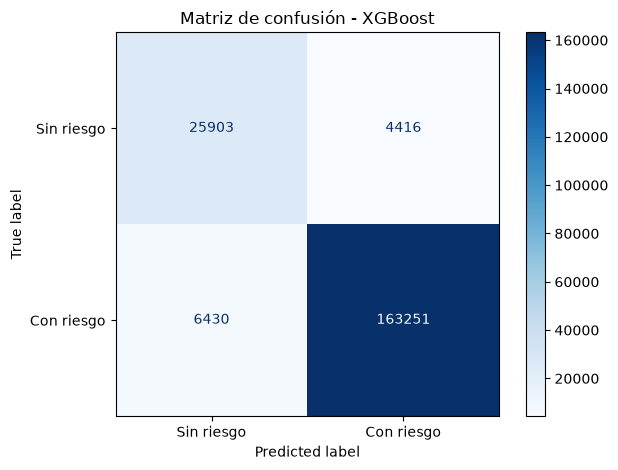

In [13]:
confusion = confusion_matrix(
    y_test,
    best_y_pred,
    labels=[0, 1]
)

display_confusion = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=[
        "Sin riesgo",
        "Con riesgo"
    ]
)

display_confusion.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    f"Matriz de confusión - {best_model_name}"
)
plt.tight_layout()

plt.savefig(
    figures_path / "confusion_matrix.png",
    dpi=120
)

plt.show()
plt.close()


## 14. Curvas ROC y Precision-Recall

Represento las curvas de los modelos para comparar su comportamiento a través de distintos umbrales.

Utilizo una figura independiente para cada curva para mantener los gráficos claros.


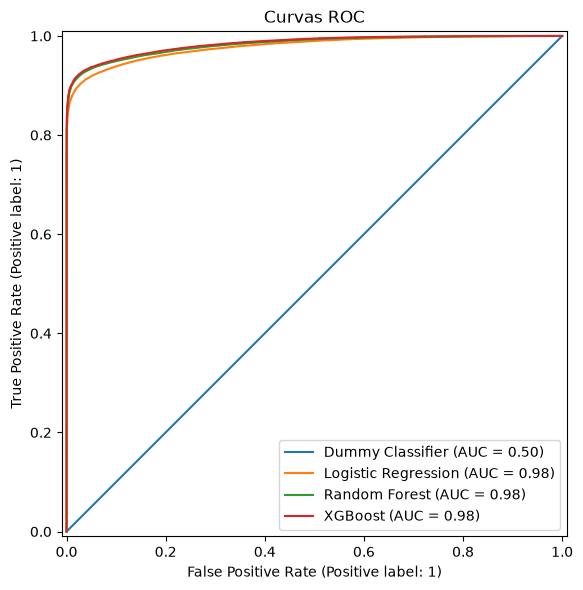

In [14]:
plt.figure(figsize=(8, 6))

for model_name, prediction_data in model_predictions.items():
    RocCurveDisplay.from_predictions(
        y_test,
        prediction_data["y_probability"],
        name=model_name,
        ax=plt.gca()
    )

plt.title("Curvas ROC")
plt.tight_layout()

plt.savefig(
    figures_path / "roc_curves.png",
    dpi=120
)

plt.show()
plt.close()


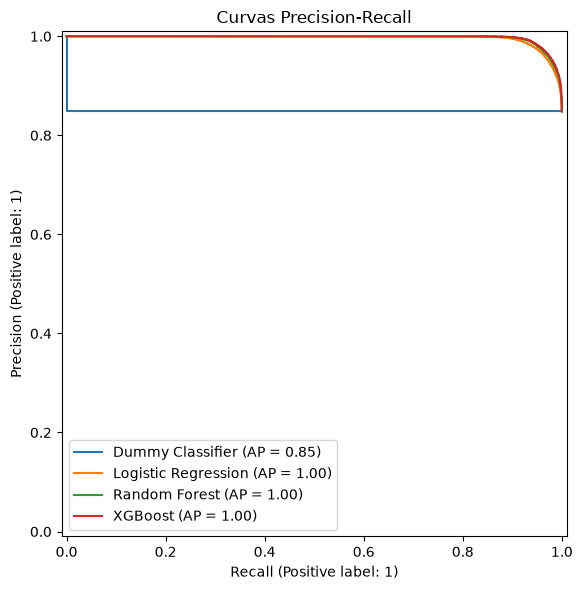

In [15]:
plt.figure(figsize=(8, 6))

for model_name, prediction_data in model_predictions.items():
    PrecisionRecallDisplay.from_predictions(
        y_test,
        prediction_data["y_probability"],
        name=model_name,
        ax=plt.gca()
    )

plt.title("Curvas Precision-Recall")
plt.tight_layout()

plt.savefig(
    figures_path / "precision_recall_curves.png",
    dpi=120
)

plt.show()
plt.close()


## 15. Importancia inicial de variables

Si el modelo seleccionado es Random Forest o XGBoost, muestro la importancia interna de sus variables.

Si el modelo es una regresión logística, utilizo el valor absoluto de sus coeficientes.

Este resultado es una primera aproximación. La explicabilidad más detallada se realizará en el siguiente notebook.


In [16]:
if best_model_name == "Logistic Regression":
    coefficients = np.abs(
        best_model.named_steps[
            "model"
        ].coef_[0]
    )

    feature_importance = pd.DataFrame({
        "feature": model_features,
        "importance": coefficients
    })

else:
    feature_importance = pd.DataFrame({
        "feature": model_features,
        "importance": best_model.feature_importances_
    })

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(feature_importance.head(15))

feature_importance.to_csv(
    metrics_path / "feature_importance.csv",
    index=False
)


,feature,importance
0,lead_time_days,0.8165
1,week,0.0618
2,month,0.0381
3,promo_days_last_7,0.0166
4,trend_7_30,0.0136
5,rolling_std_30,0.0081
6,rolling_mean_7,0.0065
7,sales,0.0064
8,rolling_mean_14,0.0054
9,rolling_mean_30,0.0052


## 16. Guardado del modelo

Guardo el modelo seleccionado y la lista de variables utilizadas.

Estos archivos serán necesarios para el notebook de explicabilidad.


In [17]:
joblib.dump(
    best_model,
    models_path / "best_stockout_model.pkl"
)

with open(
    models_path / "model_features.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_features,
        file,
        ensure_ascii=False,
        indent=4
    )

model_information = {
    "model_name": best_model_name,
    "threshold": THRESHOLD,
    "cut_date": str(
        pd.Timestamp(cut_date).date()
    ),
    "train_rows": len(train_df),
    "test_rows": len(test_df)
}

with open(
    models_path / "model_information.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_information,
        file,
        ensure_ascii=False,
        indent=4
    )

print("Modelo y configuración guardados.")


Modelo y configuración guardados.


## 17. Guardado de las predicciones

Guardo las probabilidades y las variables del conjunto de test.

Incluyo directamente las features para que el siguiente notebook no tenga que reconstruir `X_test` mediante cruces entre tablas.


In [18]:
test_predictions = test_df[
    [
        "date",
        "store_id",
        "item_id",
        *model_features
    ]
].copy()

test_predictions["y_true"] = (
    y_test.to_numpy()
)

test_predictions["y_pred"] = (
    best_y_pred
)

test_predictions["y_probability"] = (
    best_y_probability
)

test_predictions["model"] = (
    best_model_name
)

predictions_file = (
    predictions_path
    / "test_predictions_best_model.csv"
)

test_predictions.to_csv(
    predictions_file,
    index=False
)

print(
    "Predicciones guardadas en:",
    predictions_file
)

display(test_predictions.head())


Predicciones guardadas en: c:\Users\lloro\Documents\GitHub\TFE_PROYECTO1\outputs\predictions\test_predictions_best_model.csv


,date,store_id,item_id,sales,price,promo,year,month,week,weekday,is_weekend,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_30,trend_7_30,rolling_price_mean_30,promo_days_last_7,lead_time_days,y_true,y_pred,y_probability,model
0,2023-01-01,store_1,item_1,41,21.3000,0,2023,1,52,6,1,41.0000,39.0000,36.0000,38.0000,46.4286,46.5714,44.5000,10.7343,1.9286,20.8740,1.0000,2,1,1,0.9999,XGBoost
1,2023-01-01,store_1,item_16,30,43.0800,0,2023,1,52,6,1,30.0000,25.0000,23.0000,33.0000,31.1429,29.8571,29.6667,5.9962,1.4762,42.2180,0.0000,3,1,1,1.0000,XGBoost
2,2023-01-01,store_1,item_20,39,15.2400,0,2023,1,52,6,1,40.0000,41.0000,42.0000,34.0000,47.0000,46.2143,43.9333,9.1799,3.0667,15.1387,0.0000,7,0,1,0.7834,XGBoost
3,2023-01-01,store_1,item_22,11,47.5900,0,2023,1,52,6,1,13.0000,21.0000,12.0000,10.0000,19.5714,19.4286,17.4667,4.5466,2.1048,46.6380,1.0000,2,1,1,1.0000,XGBoost
4,2023-01-01,store_1,item_25,33,89.2100,0,2023,1,52,6,1,23.0000,34.0000,27.0000,31.0000,39.5714,36.6429,35.3333,8.1000,4.2381,88.0207,1.0000,5,1,1,0.9994,XGBoost


## 18. Comprobaciones finales

Compruebo que se hayan creado los principales archivos necesarios para continuar con el proyecto.


In [19]:
required_files = [
    models_path / "best_stockout_model.pkl",
    models_path / "model_features.json",
    models_path / "model_information.json",
    metrics_path / "model_metrics.csv",
    predictions_path / "test_predictions_best_model.csv"
]

for file_path in required_files:
    if not file_path.exists():
        raise FileNotFoundError(
            f"No se ha generado: {file_path}"
        )

print(
    "Todos los archivos necesarios "
    "se han generado correctamente."
)


Todos los archivos necesarios se han generado correctamente.


## 19. Conclusiones

En este notebook he:

- realizado una separación temporal entre train y test;
- limitado el tamaño de los datos para adaptar el proceso al equipo disponible;
- comparado un baseline, regresión logística, Random Forest y XGBoost;
- calculado varias métricas;
- seleccionado un modelo provisional;
- revisado su matriz de confusión;
- guardado el modelo y las predicciones.
